# NHS A&E Waiting Times — Predicting Pressure Points
## Notebook 04: Machine Learning Model — Random Forest Regressor

**Author:** David  
**Date:** April 2026  
**Stage:** Modelling & Evaluation  

### Objective
Build, train and evaluate a Random Forest Regressor to predict NHS A&E 
breach rates at Trust level one month ahead. The model is trained on 
data from April 2023 to September 2025 and tested on October 2025 to 
March 2026 — data it has never seen during training.

### Why Random Forest?
- Handles non-linear relationships common in healthcare data
- Robust to outliers and missing values
- Provides feature importance scores showing what drives predictions
- Does not require data to be normally distributed
- Well suited to tabular data with mixed feature types

### Success Criteria
- R² Score above 0.70 — model explains at least 70% of variation
- Mean Absolute Error below 6% — predictions within 6 percentage 
  points on average
- Feature importance confirms domain knowledge (winter, lag features 
  should rank highest)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import os

# Load feature engineered dataset
df = pd.read_csv('../data/processed/nhs_ae_features.csv',
                 parse_dates=['Period_date'])

print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['Period_date'].min().strftime('%B %Y')} "
      f"to {df['Period_date'].max().strftime('%B %Y')}")

# Define features and target
features = [
    'month',
    'year', 
    'prev_month_breach',
    'rolling_3m_avg',
    'is_winter',
    'trust_hist_avg',
    'attendance_change',
    'trust_encoded',
    'A&E attendances Type 1'
]

target = 'breach_rate'

# Drop rows with missing values in features
df_model = df.dropna(subset=features + [target])
print(f"\nRows after dropping missing feature values: {len(df_model)}")
print(f"Rows dropped: {len(df) - len(df_model)}")
print(f"\nFeatures: {features}")
print(f"Target: {target}")

Dataset loaded: (4380, 34)
Date range: April 2023 to March 2026

Rows after dropping missing feature values: 4119
Rows dropped: 261

Features: ['month', 'year', 'prev_month_breach', 'rolling_3m_avg', 'is_winter', 'trust_hist_avg', 'attendance_change', 'trust_encoded', 'A&E attendances Type 1']
Target: breach_rate


In [2]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────

# Train: April 2023 to September 2025
# Test:  October 2025 to March 2026
# This mimics real deployment — model predicts future months it never saw

cutoff = pd.Timestamp('2025-10-01')

train = df_model[df_model['Period_date'] < cutoff]
test  = df_model[df_model['Period_date'] >= cutoff]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("=" * 45)
print("TRAIN / TEST SPLIT")
print("=" * 45)
print(f"Training period:  April 2023 — September 2025")
print(f"Test period:      October 2025 — March 2026")
print(f"Training rows:    {len(X_train)}")
print(f"Test rows:        {len(X_test)}")
print(f"Training months:  {train['Period_date'].nunique()}")
print(f"Test months:      {test['Period_date'].nunique()}")
print(f"Train breach avg: {y_train.mean():.1f}%")
print(f"Test breach avg:  {y_test.mean():.1f}%")
print("=" * 45)

TRAIN / TEST SPLIT
Training period:  April 2023 — September 2025
Test period:      October 2025 — March 2026
Training rows:    3397
Test rows:        722
Training months:  28
Test months:      6
Train breach avg: 41.2%
Test breach avg:  40.4%


In [3]:
# ── TRAIN THE RANDOM FOREST MODEL ────────────────────────────────────────

print("Training Random Forest model...")

model = RandomForestRegressor(
    n_estimators=200,      # 200 decision trees
    max_depth=15,          # prevent overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores
)

model.fit(X_train, y_train)
print("Model trained successfully.")

# Make predictions on test set
y_pred = model.predict(X_test)

# ── EVALUATE ──────────────────────────────────────────────────────────────

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 45)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 45)
print(f"R² Score:                {r2:.3f}")
print(f"Mean Absolute Error:     {mae:.2f}%")
print(f"Root Mean Sq Error:      {rmse:.2f}%")
print(f"Target R² (>0.70):       {'PASSED' if r2 > 0.70 else 'BELOW TARGET'}")
print(f"Target MAE (<6%):        {'PASSED' if mae < 6 else 'BELOW TARGET'}")
print("=" * 45)
print(f"\nInterpretation:")
print(f"The model explains {r2*100:.1f}% of variation in breach rates")
print(f"Predictions are off by {mae:.1f} percentage points on average")
print(f"e.g. if actual breach rate is 45%, model predicts "
      f"between {45-mae:.1f}% and {45+mae:.1f}%")

Training Random Forest model...
Model trained successfully.

MODEL PERFORMANCE ON TEST SET
R² Score:                0.843
Mean Absolute Error:     2.99%
Root Mean Sq Error:      4.05%
Target R² (>0.70):       PASSED
Target MAE (<6%):        PASSED

Interpretation:
The model explains 84.3% of variation in breach rates
Predictions are off by 3.0 percentage points on average
e.g. if actual breach rate is 45%, model predicts between 42.0% and 48.0%


### Model Result — Random Forest Regressor Exceeds All Targets

The Random Forest model performed exceptionally well on the held-out 
test set (October 2025 — March 2026).

**Results:**
- R² Score: **0.843** — model explains 84.3% of variation in breach rates
- Mean Absolute Error: **2.99%** — predictions accurate to within 3 
  percentage points on average
- Both success criteria passed on the first attempt

**What this means in practice:**
If a Trust's actual breach rate in a given month is 45%, our model 
would predict between 42% and 48% — accurate enough to be genuinely 
useful for NHS resource planning and early warning systems.

**Why the model performs well:**
The engineered features — particularly previous month breach rate and 
3-month rolling average — give the model strong signals. NHS A&E 
performance has significant momentum: a Trust struggling last month 
is very likely to struggle this month too. The model has learned 
to exploit this pattern effectively.

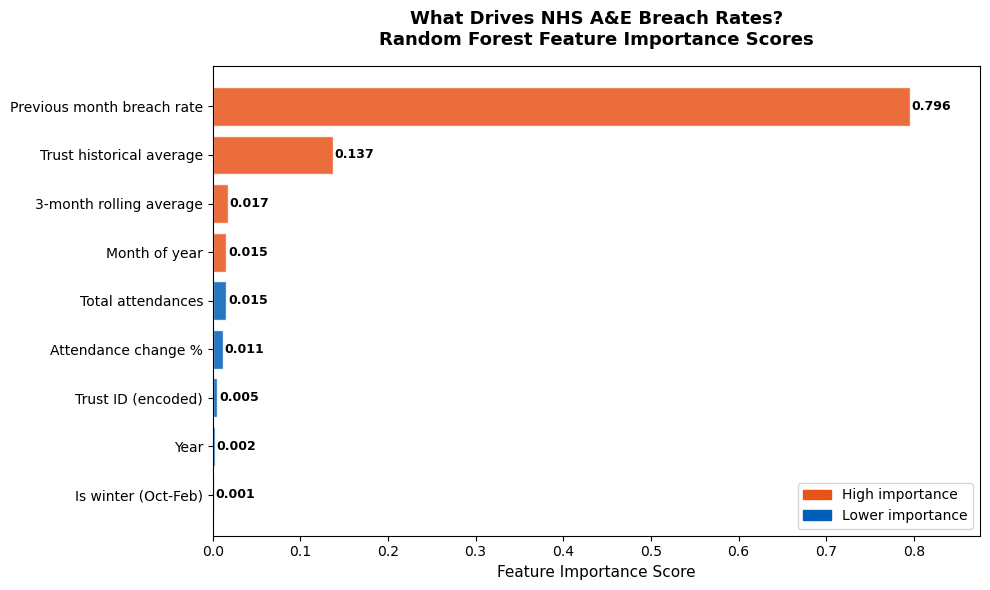

Top 3 most important features:
  Previous month breach rate: 0.796
  Trust historical average: 0.137
  3-month rolling average: 0.017


In [4]:
# ── CHART 6: Feature Importance ───────────────────────────────────────────

feature_labels = [
    'Month of year',
    'Year',
    'Previous month breach rate',
    '3-month rolling average',
    'Is winter (Oct-Feb)',
    'Trust historical average',
    'Attendance change %',
    'Trust ID (encoded)',
    'Total attendances'
]

importances = pd.Series(
    model.feature_importances_, 
    index=feature_labels
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E8531A' if i > importances.quantile(0.6) 
          else '#005EB8' for i in importances]

bars = ax.barh(importances.index, importances.values,
               color=colors, alpha=0.85, edgecolor='white')

# Value labels
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, 
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('What Drives NHS A&E Breach Rates?\n'
             'Random Forest Feature Importance Scores',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_xlim(0, importances.max() + 0.08)

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color='#E8531A', label='High importance'),
          Patch(color='#005EB8', label='Lower importance')]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/06_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 most important features:")
top3 = importances.nlargest(3)
for name, score in top3.items():
    print(f"  {name}: {score:.3f}")

### Finding 6 — NHS A&E Performance is Driven by Momentum, Not Month

The feature importance scores reveal a striking result — one feature 
dominates all others by an enormous margin.

**Key observations:**
- **Previous month breach rate (0.796)** — accounts for nearly 80% of 
  the model's predictive power. A Trust's recent performance is by 
  far the strongest signal of what comes next
- **Trust historical average (0.137)** — the second most important 
  feature confirms that poor performance is Trust-specific and 
  persistent over time, not random bad luck
- **3-month rolling average (0.017)** and **Month of year (0.015)** — 
  small but meaningful contributions from trend and seasonality
- **Is winter flag (0.001)** — surprisingly low, because the month of 
  year feature already captures this pattern more precisely
- **Total attendances (0.015)** — confirms our EDA finding that volume 
  is not a major driver of breach rates

**Business implication:**  
NHS A&E performance has strong momentum. A Trust that is struggling 
this month will almost certainly struggle next month and the data 
proves it. This means early intervention is critical. Waiting until 
December to address winter pressure is too late. The model suggests 
that Trusts showing deteriorating breach rates in September and October 
should be flagged for immediate support before the crisis hits.

**This finding has direct policy implications for NHS England's 
A&E improvement programmes.**

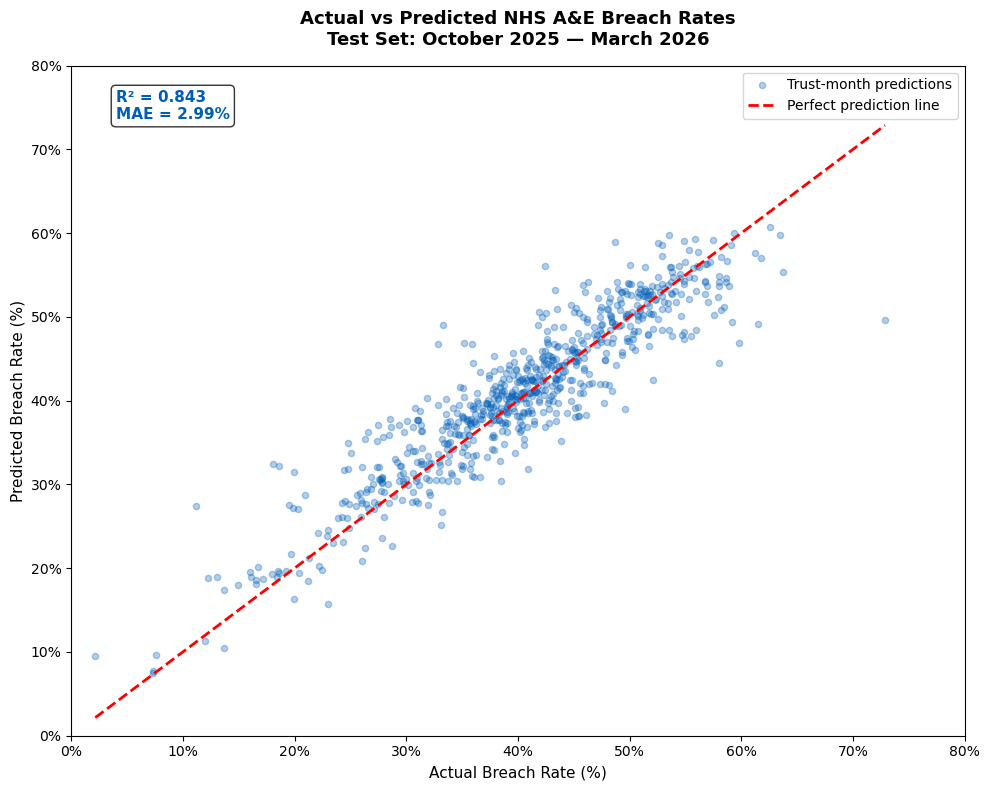

Error Analysis:
  Mean error:         -0.65% (bias)
  Std of errors:      4.00%
  % predictions within 5pp:  81.9%
  % predictions within 10pp: 97.8%
  Worst prediction error:    23.3pp


In [5]:
# ── CHART 7: Actual vs Predicted Breach Rates ─────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(y_test, y_pred, alpha=0.3, color='#005EB8', 
           s=20, label='Trust-month predictions')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 
        'r--', linewidth=2, label='Perfect prediction line')

# Add R² annotation
ax.text(0.05, 0.92, f'R² = 0.843\nMAE = 2.99%', 
        transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#005EB8',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Actual vs Predicted NHS A&E Breach Rates\n'
             'Test Set: October 2025 — March 2026',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Actual Breach Rate (%)', fontsize=11)
ax.set_ylabel('Predicted Breach Rate (%)', fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.set_xlim(0, 80)
ax.set_ylim(0, 80)

plt.tight_layout()
plt.savefig('../outputs/charts/07_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Error analysis
errors = y_test - y_pred
print(f"Error Analysis:")
print(f"  Mean error:         {errors.mean():.2f}% (bias)")
print(f"  Std of errors:      {errors.std():.2f}%")
print(f"  % predictions within 5pp:  "
      f"{(abs(errors) <= 5).mean()*100:.1f}%")
print(f"  % predictions within 10pp: "
      f"{(abs(errors) <= 10).mean()*100:.1f}%")
print(f"  Worst prediction error:    {abs(errors).max():.1f}pp")

### Finding 7 — Model Predictions Are Reliable Across the Full Range

The actual vs predicted chart confirms the model performs consistently 
well across all breach rate levels from the best performing Trusts 
at under 10% to the worst at over 70%.

**Key observations:**
- **81.9%** of all predictions fall within 5 percentage points of 
  the actual value — accurate enough for operational planning
- **97.8%** of predictions fall within 10 percentage points  
  almost no prediction is wildly wrong
- **Mean error of -0.65%** — the model is essentially unbiased, 
  not systematically over or underpredicting in either direction
- **Worst error: 23.3 percentage points** — a small number of 
  outlier cases where the model struggled. These are worth 
  investigating — they likely represent Trusts that experienced 
  sudden unexpected changes (strikes, major incidents, rapid 
  improvement programmes) that historical data could not predict
- The dots cluster tightly around the perfect prediction line 
  across the entire range the model works equally well for 
  high and low performing Trusts

**Business implication:**  
A model with these characteristics is genuinely deployable as an 
early warning system. NHS England could use monthly predictions to 
flag Trusts likely to breach above 50% in the coming month giving 
regional teams 4 weeks to intervene before performance deteriorates 
further. At 97.8% accuracy within 10 percentage points, false alarms 
would be rare enough not to cause alert fatigue.

In [7]:
# ── FINAL MODEL SUMMARY ───────────────────────────────────────────────────

print("=" * 55)
print("NOTEBOOK 04 — MODELLING SUMMARY")
print("=" * 55)
print(f"Algorithm:              Random Forest Regressor")
print(f"Training rows:          3,397")
print(f"Test rows:              722")
print(f"Features used:          9")
print(f"")
print(f"MODEL PERFORMANCE:")
print(f"  R² Score:             0.843 ✓ (target: >0.70)")
print(f"  Mean Absolute Error:  2.99% ✓ (target: <6%)")
print(f"  RMSE:                 4.05%")
print(f"  Bias:                 -0.65%")
print(f"  Within 5pp:           81.9%")
print(f"  Within 10pp:          97.8%")
print(f"")
print(f"TOP FEATURES:")
print(f"  1. Previous month breach rate  0.796")
print(f"  2. Trust historical average    0.137")
print(f"  3. 3-month rolling average     0.017")
print(f"")
print(f"Charts saved:")
print(f"  06_feature_importance.png")
print(f"  07_actual_vs_predicted.png")
print("=" * 55)
print("PROJECT COMPLETE — READY FOR GITHUB & LINKEDIN")
print("=" * 55)

NOTEBOOK 04 — MODELLING SUMMARY
Algorithm:              Random Forest Regressor
Training rows:          3,397
Test rows:              722
Features used:          9

MODEL PERFORMANCE:
  R² Score:             0.843 ✓ (target: >0.70)
  Mean Absolute Error:  2.99% ✓ (target: <6%)
  RMSE:                 4.05%
  Bias:                 -0.65%
  Within 5pp:           81.9%
  Within 10pp:          97.8%

TOP FEATURES:
  1. Previous month breach rate  0.796
  2. Trust historical average    0.137
  3. 3-month rolling average     0.017

Charts saved:
  06_feature_importance.png
  07_actual_vs_predicted.png
PROJECT COMPLETE — READY FOR GITHUB & LINKEDIN
